In [1]:
import numpy as np
import pandas as pd
import os

In [2]:
import tensorflow as tf

print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))
print("GPUs: ", tf.config.list_physical_devices('GPU'))

2026-03-15 15:17:45.400733: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773587865.636521      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773587865.702900      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773587866.264362      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773587866.264398      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773587866.264401      55 computation_placer.cc:177] computation placer alr

Num GPUs Available:  2
GPUs:  [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [3]:
fake=pd.read_csv("/kaggle/input/datasets/bhavikjikadara/fake-news-detection/fake.csv")
true=pd.read_csv("/kaggle/input/datasets/bhavikjikadara/fake-news-detection/true.csv")

In [4]:
fake.head()

,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


In [5]:
true.head()

,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


In [6]:
fake.drop(columns=['subject','date'],inplace=True)

In [7]:
true.drop(columns=['subject','date'],inplace=True)

In [8]:
fake.head()

,title,text
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk..."
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ..."
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...


In [9]:
true.head()

,title,text
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...


In [10]:
fake['label']=0

In [11]:
true['label']=1

In [12]:
fake.head()

,title,text,label
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,0
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,0
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",0
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",0
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,0


In [13]:
true.head()

,title,text,label
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,1
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,1
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,1
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,1
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,1


In [14]:
data=pd.concat([true,fake],ignore_index=True)

In [15]:
data=data.reset_index(drop=True)


In [17]:
data.sample(10)

,title,text,label
39897,TENNESSEE: ARMED FUGITIVES Wanted For Murder O...,Feel good story of the day Two escaped inmates...,0
39365,LIBERAL HOLLYWOOD IMPLODES! Ratings Are In For...,This summer s box office numbers were the wors...,0
17645,U.S. believes current North Korea nuclear thre...,WASHINGTON (Reuters) - White House Chief of St...,1
22510,WATCH: GOP-Friendly PAC Creates SICKENING Lin...,A PAC that claims to support principled conse...,0
33244,LOL! Lifetime Politician Who Got 2% Support Fr...,"Lindsey Graham, the South Carolina Republican ...",0
14535,"Serbian, U.S. army paratroopers jump together ...",BELGRADE (Reuters) - Paratroopers from Serbia ...,1
12900,Jordan rejects Trump's move on Jerusalem as le...,AMMAN (Reuters) - Jordan on Wednesday rejected...,1
35540,TAKE A LOOK INSIDE THE NEW “PUTIN CAFE” Featur...,The majority of Americans would likely find th...,0
20987,Putin warns U.S. not to supply Ukraine with de...,"XIAMEN, China (Reuters) - Russian President Vl...",1
12823,Trump recognizes Jerusalem as Israel's capital...,WASHINGTON/JERUSALEM (Reuters) - President Don...,1


In [18]:
import re
import string


In [19]:
english_punctuations = string.punctuation

In [20]:
import nltk

In [21]:
from nltk.corpus import stopwords
stopwords_en = set(stopwords.words('english'))

In [22]:
import nltk
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet


In [23]:
lemmatizer = WordNetLemmatizer()

In [24]:
from tqdm import tqdm

In [25]:
import emoji

In [26]:
nltk.download("omw-1.4")
nltk.download("punkt")
nltk.download("wordnet")

[nltk_data] Downloading package omw-1.4 to /usr/share/nltk_data...
[nltk_data] Downloading package punkt to /usr/share/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /usr/share/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [27]:
for col in ['title','text']:
    data[col]=data[col].str.lower()

In [28]:
data.head()

,title,text,label
0,"as u.s. budget fight looms, republicans flip t...",washington (reuters) - the head of a conservat...,1
1,u.s. military to accept transgender recruits o...,washington (reuters) - transgender people will...,1
2,senior u.s. republican senator: 'let mr. muell...,washington (reuters) - the special counsel inv...,1
3,fbi russia probe helped by australian diplomat...,washington (reuters) - trump campaign adviser ...,1
4,trump wants postal service to charge 'much mor...,seattle/washington (reuters) - president donal...,1


In [29]:
pip install contractions

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 9.2 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [30]:

import contractions

In [ ]:
# import emoji
# import re

# def emoji_to_words(text):
#     text = emoji.demojize(str(text))
#     text = text.replace(":", " ")
#     text = text.replace("_", " ")
#     text = re.sub(r'\s+', ' ', text).strip()
#     return text

# data['text_with_emoji_meaning'] = data['text'].apply(emoji_to_words)

In [31]:
for col in ['title','text']:
    data[col]=data[col].apply(lambda x: contractions.fix(x))

In [32]:
for col in ['title','text']:
    data[col]=data[col].str.replace(r"http\S+|https\S+|www\S+","",regex=True)

In [33]:
string.punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [34]:
for col in ['title','text']:
    data[col]=data[col].str.replace(f"[{string.punctuation}]","",regex=True)

In [35]:
data.head()

,title,text,label
0,as yous budget fight looms republicans flip th...,washington reuters the head of a conservative...,1
1,yous military to accept transgender recruits o...,washington reuters transgender people will be...,1
2,senior yous republican senator let mr mueller ...,washington reuters the special counsel invest...,1
3,fbi russia probe helped by australian diplomat...,washington reuters trump campaign adviser geo...,1
4,trump wants postal service to charge much more...,seattlewashington reuters president donald tr...,1


In [36]:
def remove_stopwords(text):
    words=text.lower().split()
    filtered=[words for word in words if word not in stopwords_en]
    return filtered

In [38]:
data['corrected_text']=data['text'].apply(remove_stopwords)

In [39]:
data.head()

,title,text,label,corrected_text
0,as yous budget fight looms republicans flip th...,washington reuters the head of a conservative...,1,"[[washington, reuters, the, head, of, a, conse..."
1,yous military to accept transgender recruits o...,washington reuters transgender people will be...,1,"[[washington, reuters, transgender, people, wi..."
2,senior yous republican senator let mr mueller ...,washington reuters the special counsel invest...,1,"[[washington, reuters, the, special, counsel, ..."
3,fbi russia probe helped by australian diplomat...,washington reuters trump campaign adviser geo...,1,"[[washington, reuters, trump, campaign, advise..."
4,trump wants postal service to charge much more...,seattlewashington reuters president donald tr...,1,"[[seattlewashington, reuters, president, donal..."


In [40]:
import spacy

In [41]:
nlp=spacy.load("en_core_web_sm")

In [42]:
def lemmatize_text(text):
    
    # If it's already a list → join first
    if isinstance(text, list):
        # flatten nested list if needed
        if len(text) > 0 and isinstance(text[0], list):
            text = text[0]
        text = " ".join(map(str, text))
    
    # If it's NaN
    if text is None:
        return ""
    
    # Convert to string safely
    text = str(text)

    doc = nlp(text)
    
    return " ".join(
        token.lemma_
        for token in doc
        if token.is_alpha and not token.is_stop
    )

In [48]:
from tqdm import tqdm
tqdm.pandas()

In [49]:
data['corrected']=data['corrected_text'].progress_apply(lemmatize_text)

100%|██████████| 44898/44898 [37:00<00:00, 20.22it/s] 


In [55]:
data.head()

,title,text,label,corrected_text,corrected
0,as yous budget fight looms republicans flip th...,washington reuters the head of a conservative...,1,"[[washington, reuters, the, head, of, a, conse...",washington reuters head conservative republica...
1,yous military to accept transgender recruits o...,washington reuters transgender people will be...,1,"[[washington, reuters, transgender, people, wi...",washington reuters transgender people allow ti...
2,senior yous republican senator let mr mueller ...,washington reuters the special counsel invest...,1,"[[washington, reuters, the, special, counsel, ...",washington reuters special counsel investigati...
3,fbi russia probe helped by australian diplomat...,washington reuters trump campaign adviser geo...,1,"[[washington, reuters, trump, campaign, advise...",washington reuters trump campaign adviser geor...
4,trump wants postal service to charge much more...,seattlewashington reuters president donald tr...,1,"[[seattlewashington, reuters, president, donal...",seattlewashington reuters president donald tru...


In [56]:
from sklearn.feature_extraction.text import CountVectorizer

In [57]:
data['label'].value_counts()

label
0    23481
1    21417
Name: count, dtype: int64

In [58]:
cv=CountVectorizer(max_features=15000,ngram_range=(1,2),min_df=3)

In [59]:
from sklearn.model_selection import train_test_split

In [61]:
x,y=data['corrected'],data['label']

In [62]:
x_train,x_test,y_train_b,y_test_b=train_test_split(x,y,test_size=0.3,random_state=42)

In [63]:
x_train_bow = cv.fit_transform(x_train)

In [64]:
x_test_bow = cv.transform(x_test)

In [65]:
from sklearn.linear_model import LogisticRegression

In [66]:
clf = LogisticRegression(max_iter=2000,verbose=1)
clf.fit(x_train_bow, y_train_b)
y_pred = clf.predict(x_test_bow)

[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    2.7s finished


In [67]:
from sklearn.metrics import classification_report,confusion_matrix

In [68]:
from sklearn.metrics import accuracy_score

In [69]:
accuracy_score(y_test_b,y_pred)

0.9959910913140312

In [70]:
import seaborn as sns 
import matplotlib.pyplot as plt

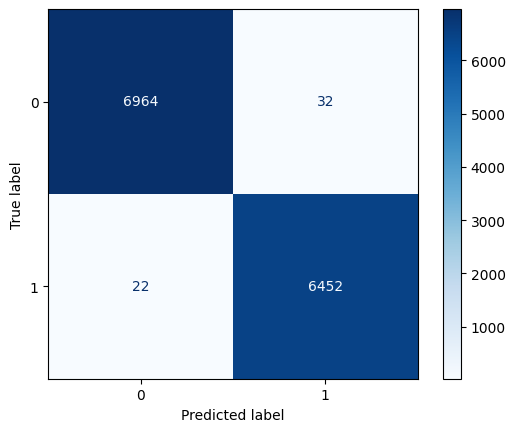

In [71]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test_b, y_pred, cmap="Blues")
plt.show()

In [72]:
from sklearn.ensemble import RandomForestClassifier

In [73]:
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

In [74]:
rf.fit(x_train_bow,y_train_b)

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done  42 tasks      | elapsed:    6.8s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:   15.6s finished


RandomForestClassifier(n_jobs=-1, random_state=42, verbose=1)

In [75]:
accuracy_score(y_test_b,y_pred)

0.9959910913140312

In [76]:
print(classification_report(y_test_b,y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      6996
           1       1.00      1.00      1.00      6474

    accuracy                           1.00     13470
   macro avg       1.00      1.00      1.00     13470
weighted avg       1.00      1.00      1.00     13470



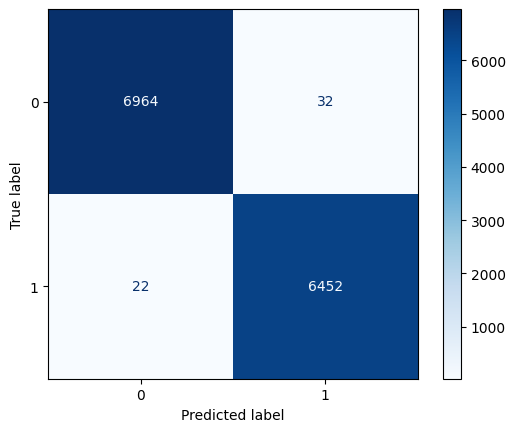

In [77]:
ConfusionMatrixDisplay.from_predictions(y_test_b,y_pred,cmap='Blues')
plt.show()

In [78]:
from sklearn.svm import LinearSVC
svm= LinearSVC(verbose=1)

In [79]:
svm.fit(x_train_bow,y_train_b)
preds = svm.predict(x_test_bow)
accuracy_score(y_test_b,preds)

[LibLinear]iter  1 act 2.600e+04 pre 2.450e+04 delta 8.107e-01 f 3.143e+04 |g| 1.539e+05 CG   7
cg reaches trust region boundary
iter  2 act 3.832e+03 pre 3.268e+03 delta 9.925e-01 f 5.432e+03 |g| 2.682e+04 CG  10
cg reaches trust region boundary
iter  3 act 1.184e+03 pre 1.035e+03 delta 1.167e+00 f 1.600e+03 |g| 1.078e+04 CG  16
cg reaches trust region boundary
iter  4 act 3.329e+02 pre 3.095e+02 delta 1.265e+00 f 4.162e+02 |g| 3.210e+03 CG  22
iter  5 act 6.032e+01 pre 6.078e+01 delta 1.265e+00 f 8.323e+01 |g| 1.135e+03 CG  23
iter  6 act 8.880e+00 pre 1.148e+01 delta 1.265e+00 f 2.291e+01 |g| 4.360e+02 CG  24
iter  7 act 2.979e+00 pre 3.155e+00 delta 1.265e+00 f 1.403e+01 |g| 2.159e+02 CG  13
cg reaches trust region boundary
iter  8 act -3.796e+02 pre 2.090e+00 delta 3.161e-01 f 1.105e+01 |g| 6.563e+01 CG  68
cg reaches trust region boundary
iter  8 act -9.203e+00 pre 9.902e-01 delta 7.904e-02 f 1.105e+01 |g| 6.563e+01 CG  41
cg reaches trust region boundary
iter  8 act 2.706e-01 pr

0.9957683741648107

In [80]:
print(classification_report(y_test_b,preds))

              precision    recall  f1-score   support

           0       1.00      0.99      1.00      6996
           1       0.99      1.00      1.00      6474

    accuracy                           1.00     13470
   macro avg       1.00      1.00      1.00     13470
weighted avg       1.00      1.00      1.00     13470



In [82]:
from sklearn.feature_extraction.text import TfidfVectorizer


tf = TfidfVectorizer(max_features=15000, stop_words='english')

In [83]:
x_train,x_test,y_train_tf,y_test_tf=train_test_split(x,y,test_size=0.3,random_state=42)

In [84]:
x_train_tf=tf.fit_transform(x_train)
x_test_tf=tf.transform(x_test)

In [85]:
lg_tf = LogisticRegression(max_iter=2000,verbose=1)

In [86]:
lg_tf.fit(x_train_tf,y_train_tf)
y_pred_lg=lg_tf.predict(x_test_tf)

accuracy_score(y_test_tf,y_pred_lg)
print(classification_report(y_test_tf,y_pred_lg))

              precision    recall  f1-score   support

           0       0.99      0.98      0.99      6996
           1       0.98      0.99      0.99      6474

    accuracy                           0.99     13470
   macro avg       0.99      0.99      0.99     13470
weighted avg       0.99      0.99      0.99     13470



[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    2.7s finished


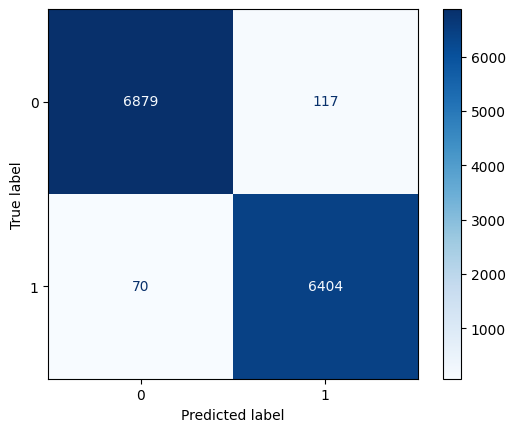

In [87]:
ConfusionMatrixDisplay.from_predictions(y_test_tf,y_pred_lg,cmap='Blues')
plt.show()

In [88]:
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done  42 tasks      | elapsed:    7.4s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:   16.9s finished
[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.1s


0.9930957683741648


[Parallel(n_jobs=4)]: Done 100 out of 100 | elapsed:    0.3s finished


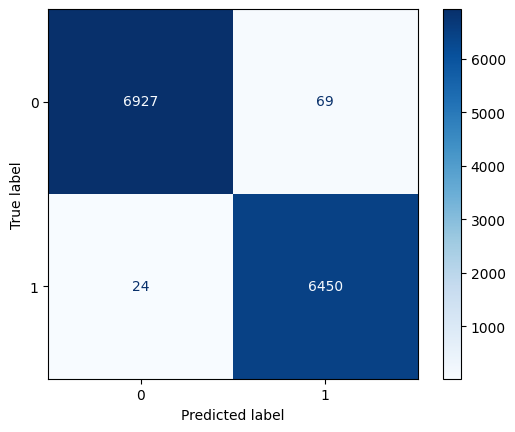

In [89]:
rf.fit(x_train_tf,y_train_tf)
y_pred_rf=rf.predict(x_test_tf)
print(accuracy_score(y_test_tf,y_pred_rf))
ConfusionMatrixDisplay.from_predictions(y_test_tf,y_pred_rf,cmap="Blues")
plt.show()

In [90]:
from sklearn.tree import DecisionTreeClassifier

In [91]:
dt=DecisionTreeClassifier()
dt.fit(x_train_tf,y_train_tf)
y_pred_dt=dt.predict(x_test_tf)

0.9936896807720861
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      6996
           1       0.99      0.99      0.99      6474

    accuracy                           0.99     13470
   macro avg       0.99      0.99      0.99     13470
weighted avg       0.99      0.99      0.99     13470



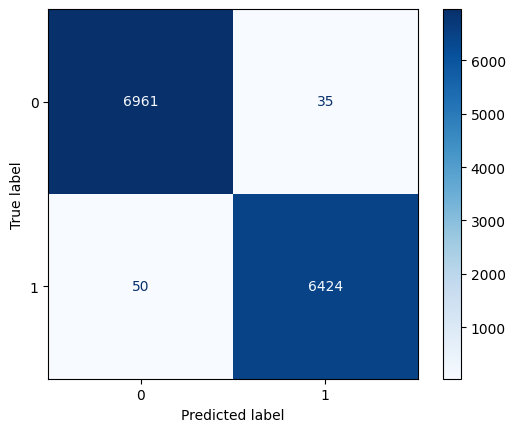

In [92]:
print(accuracy_score(y_test_tf,y_pred_dt))
print(classification_report(y_test_tf,y_pred_dt))
ConfusionMatrixDisplay.from_predictions(y_test_tf,y_pred_dt,cmap="Blues")
plt.show()

In [93]:
!pip install lightgbm

In [94]:
import lightgbm as lgb

In [95]:
lgbm = lgb.LGBMClassifier(verbose=1)

[LightGBM] [Info] Number of positive: 14943, number of negative: 16485
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 2.715406 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 774352
[LightGBM] [Info] Number of data points in the train set: 31428, number of used features: 12959
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.475468 -> initscore=-0.098208
[LightGBM] [Info] Start training from score -0.098208
0.9968819599109131
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      6996
           1       1.00      1.00      1.00      6474

    accuracy                           1.00     13470
   macro avg       1.00      1.00      1.00     13470
weighted avg       1.00      1.00      1.00     13470



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


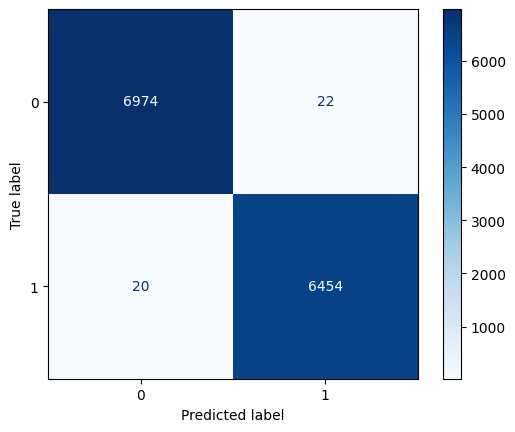

In [96]:
lgbm.fit(x_train_tf, y_train_tf)
y_pred_lgbm=lgbm.predict(x_test_tf)
print(accuracy_score(y_test_tf,y_pred_lgbm))
print(classification_report(y_test_tf,y_pred_lgbm))
ConfusionMatrixDisplay.from_predictions(y_test_tf,y_pred_lgbm,cmap="Blues")
plt.show()

In [97]:
!pip install catboost

In [98]:
from catboost import CatBoostClassifier

0:	learn: 0.9894998	total: 1.06s	remaining: 3m 31s
1:	learn: 0.9894680	total: 1.76s	remaining: 2m 54s
2:	learn: 0.9905498	total: 2.58s	remaining: 2m 49s
3:	learn: 0.9905498	total: 3.31s	remaining: 2m 42s
4:	learn: 0.9912817	total: 4.01s	remaining: 2m 36s
5:	learn: 0.9924590	total: 4.7s	remaining: 2m 31s
6:	learn: 0.9924271	total: 5.4s	remaining: 2m 28s
7:	learn: 0.9923953	total: 6.11s	remaining: 2m 26s
8:	learn: 0.9925226	total: 6.82s	remaining: 2m 24s
9:	learn: 0.9926180	total: 7.53s	remaining: 2m 23s
10:	learn: 0.9926499	total: 8.27s	remaining: 2m 22s
11:	learn: 0.9929999	total: 8.97s	remaining: 2m 20s
12:	learn: 0.9931590	total: 9.68s	remaining: 2m 19s
13:	learn: 0.9932226	total: 10.4s	remaining: 2m 17s
14:	learn: 0.9933181	total: 11.1s	remaining: 2m 16s
15:	learn: 0.9933499	total: 11.8s	remaining: 2m 15s
16:	learn: 0.9934453	total: 12.5s	remaining: 2m 14s
17:	learn: 0.9935090	total: 13.3s	remaining: 2m 13s
18:	learn: 0.9935408	total: 14s	remaining: 2m 13s
19:	learn: 0.9936362	total

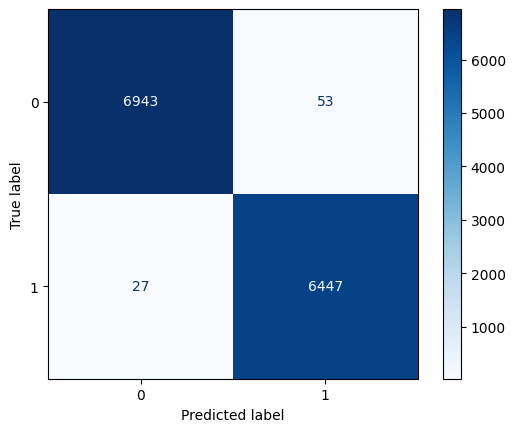

In [99]:
 model =  CatBoostClassifier(
    iterations=200,    
    learning_rate=0.05,  
    depth=6,             
    eval_metric='Accuracy',
    random_seed=42
)
model.fit(x_train_tf, y_train_tf)
y_pred_cat=model.predict(x_test_tf)
print(accuracy_score(y_test_tf,y_pred_cat))
print(classification_report(y_test_tf,y_pred_cat))
ConfusionMatrixDisplay.from_predictions(y_test_tf,y_pred_cat,cmap="Blues")
plt.show()

In [100]:
from sklearn.ensemble import GradientBoostingClassifier

In [101]:
gbc = GradientBoostingClassifier(
    n_estimators=100,   # Number of trees
    learning_rate=0.1,  # Step size
    max_depth=3,        # Depth of each tree
    random_state=42,
    verbose=1
)

      Iter       Train Loss   Remaining Time 
         1           1.1983            3.17m
         2           1.0463            3.09m
         3           0.9198            3.04m
         4           0.8128            3.00m
         5           0.7215            2.97m
         6           0.6429            2.95m
         7           0.5748            2.91m
         8           0.5155            2.87m
         9           0.4635            2.84m
        10           0.4179            2.81m
        20           0.1672            2.49m
        30           0.0840            2.17m
        40           0.0556            1.86m
        50           0.0453            1.55m
        60           0.0410            1.23m
        70           0.0381           55.43s
        80           0.0360           36.91s
        90           0.0340           18.43s
       100           0.0324            0.00s
0.9943578322197476
              precision    recall  f1-score   support

           0       1.00  

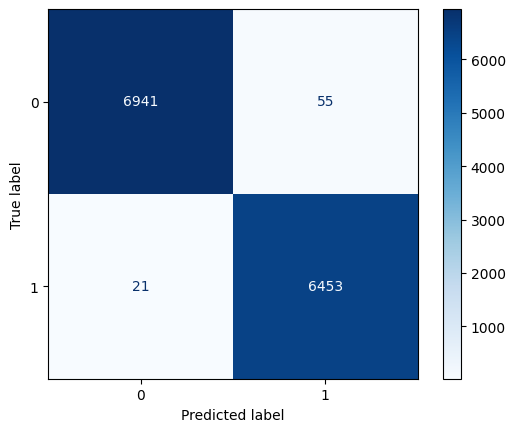

In [102]:
gbc.fit(x_train_tf,y_train_tf)
y_pred_gbc=gbc.predict(x_test_tf)
print(accuracy_score(y_test_tf,y_pred_gbc))
print(classification_report(y_test_tf,y_pred_gbc))
ConfusionMatrixDisplay.from_predictions(y_test_tf,y_pred_gbc,cmap="Blues")
plt.show()

[LibLinear]iter  1 act 2.730e+04 pre 2.638e+04 delta 1.609e+01 f 3.143e+04 |g| 5.322e+03 CG   5
cg reaches trust region boundary
iter  2 act 2.429e+03 pre 2.144e+03 delta 1.877e+01 f 4.130e+03 |g| 6.149e+02 CG   9
iter  3 act 5.183e+02 pre 4.757e+02 delta 1.877e+01 f 1.701e+03 |g| 1.967e+02 CG  13
iter  4 act 7.070e+01 pre 6.539e+01 delta 1.877e+01 f 1.182e+03 |g| 6.449e+01 CG  13
iter  5 act 1.129e+01 pre 1.101e+01 delta 1.877e+01 f 1.112e+03 |g| 1.630e+01 CG  16
iter  6 act 6.197e-01 pre 6.166e-01 delta 1.877e+01 f 1.100e+03 |g| 2.715e+00 CG  17
iter  7 act 7.211e-03 pre 7.212e-03 delta 1.877e+01 f 1.100e+03 |g| 2.732e-01 CG  17
0.9943578322197476


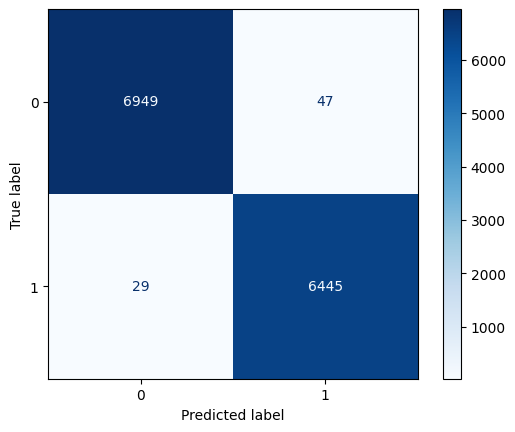

In [103]:
svm= LinearSVC(verbose=1)
svm.fit(x_train_tf,y_train_tf)
preds = svm.predict(x_test_tf)
print(accuracy_score(y_test_tf,preds))
ConfusionMatrixDisplay.from_predictions(y_test_tf,preds,cmap="Blues")
plt.show()

In [104]:
!pip install gensim

In [105]:
import gensim
print(gensim.__version__)

4.4.0


In [106]:
from gensim.models import Word2Vec

In [107]:
sentences = data['corrected'].apply(lambda x: x.split()).tolist()

In [108]:
x_train, x_test, y_train_w, y_test_w = train_test_split(sentences, y, test_size=0.3, random_state=42)

In [109]:
model = Word2Vec(
    sentences=x_train,
    vector_size=300,   # embedding dimension
    window=5,          # context window
    min_count=2,       # ignore rare words
    sg=0,              # 1 = Skip-Gram, 0 = CBOW
    workers=-1,         # parallel threads
    epochs=10
)

In [110]:
model.save("word2vec_model.model")

In [114]:
words = list(model.wv.index_to_key)
print(words[10:20])

['tell', 'government', 'clinton', 'donald', 'house', 'obama', 'republican', 'country', 'time', 'go']


In [115]:
vector = model.wv['say']  # 'example' must be in your vocabulary
print(vector.shape)

(300,)


In [116]:
import numpy as np

def document_vector(tokens):

    tokens = [word for word in tokens if word in model.wv.index_to_key]
    if len(tokens) == 0:
        return np.zeros(model.vector_size)
    return np.mean(model.wv[tokens], axis=0)




In [117]:
X_train_w = np.array([document_vector(tokens) for tokens in x_train])
X_test_w  = np.array([document_vector(tokens) for tokens in x_test])

0.5193763919821827
              precision    recall  f1-score   support

           0       0.52      1.00      0.68      6996
           1       0.00      0.00      0.00      6474

    accuracy                           0.52     13470
   macro avg       0.26      0.50      0.34     13470
weighted avg       0.27      0.52      0.36     13470



[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize(

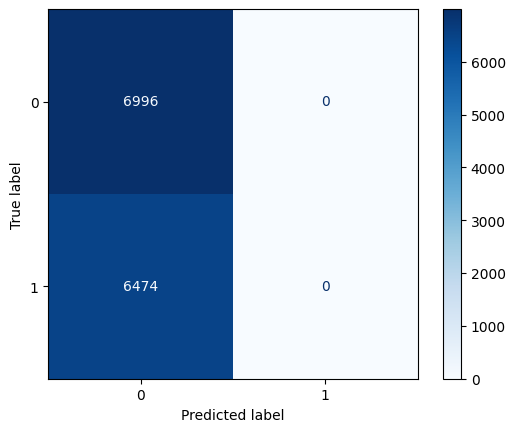

In [118]:
lg_w=LogisticRegression(max_iter=2000,verbose=1)
lg_w.fit(X_train_w,y_train_w)
y_pred_lg=lg_w.predict(X_test_w)
print(accuracy_score(y_test_w,y_pred_lg))
print(classification_report(y_test_w,y_pred_lg))
ConfusionMatrixDisplay.from_predictions(y_test_w,y_pred_lg,cmap="Blues")
plt.show()

In [119]:
rf_w = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done  42 tasks      | elapsed:   11.0s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:   25.3s finished
[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.0s
[Parallel(n_jobs=4)]: Done 100 out of 100 | elapsed:    0.1s finished


0.929101707498144
              precision    recall  f1-score   support

           0       0.93      0.93      0.93      6996
           1       0.93      0.92      0.93      6474

    accuracy                           0.93     13470
   macro avg       0.93      0.93      0.93     13470
weighted avg       0.93      0.93      0.93     13470



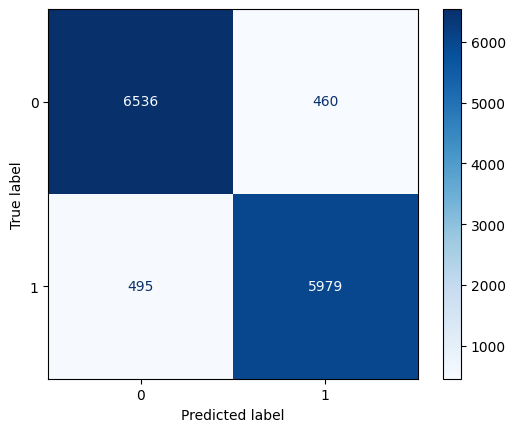

In [120]:
rf_w.fit(X_train_w,y_train_w)
y_pred_rf_w=rf_w.predict(X_test_w)
print(accuracy_score(y_test_w,y_pred_rf_w))
print(classification_report(y_test_w,y_pred_rf_w))
ConfusionMatrixDisplay.from_predictions(y_test_w,y_pred_rf_w,cmap="Blues")
plt.show()

[LightGBM] [Info] Number of positive: 14943, number of negative: 16485
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.059113 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 76500
[LightGBM] [Info] Number of data points in the train set: 31428, number of used features: 300
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.475468 -> initscore=-0.098208
[LightGBM] [Info] Start training from score -0.098208
0.94090571640683
              precision    recall  f1-score   support

           0       0.94      0.94      0.94      6996
           1       0.94      0.94      0.94      6474

    accuracy                           0.94     13470
   macro avg       0.94      0.94      0.94     13470
weighted avg       0.94      0.94      0.94     13470



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


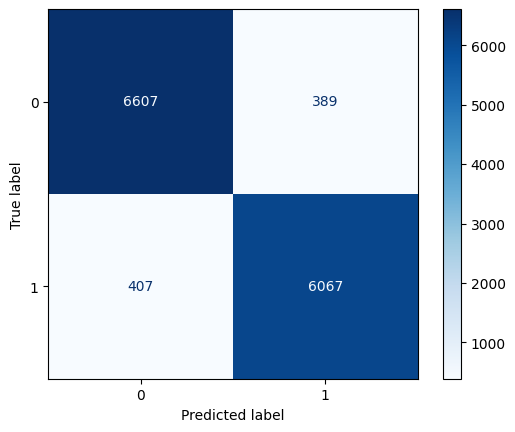

In [121]:
lgbm.fit(X_train_w,y_train_w)
y_pred_lgbm=lgbm.predict(X_test_w)
print(accuracy_score(y_test_w,y_pred_lgbm))
print(classification_report(y_test_w,y_pred_lgbm))
ConfusionMatrixDisplay.from_predictions(y_test_w,y_pred_lgbm,cmap="Blues")
plt.show()

Learning rate set to 0.044904
0:	learn: 0.6713387	total: 70.4ms	remaining: 1m 10s
1:	learn: 0.6532757	total: 125ms	remaining: 1m 2s
2:	learn: 0.6356503	total: 177ms	remaining: 58.7s
3:	learn: 0.6189956	total: 232ms	remaining: 57.8s
4:	learn: 0.6035285	total: 286ms	remaining: 57s
5:	learn: 0.5900067	total: 338ms	remaining: 56.1s
6:	learn: 0.5773421	total: 392ms	remaining: 55.6s
7:	learn: 0.5652609	total: 445ms	remaining: 55.2s
8:	learn: 0.5536181	total: 499ms	remaining: 54.9s
9:	learn: 0.5437267	total: 551ms	remaining: 54.6s
10:	learn: 0.5334949	total: 603ms	remaining: 54.2s
11:	learn: 0.5247607	total: 656ms	remaining: 54s
12:	learn: 0.5161656	total: 709ms	remaining: 53.8s
13:	learn: 0.5080139	total: 760ms	remaining: 53.5s
14:	learn: 0.4996958	total: 811ms	remaining: 53.2s
15:	learn: 0.4922102	total: 863ms	remaining: 53.1s
16:	learn: 0.4852748	total: 916ms	remaining: 53s
17:	learn: 0.4791299	total: 970ms	remaining: 52.9s
18:	learn: 0.4726453	total: 1.02s	remaining: 52.6s
19:	learn: 0.46

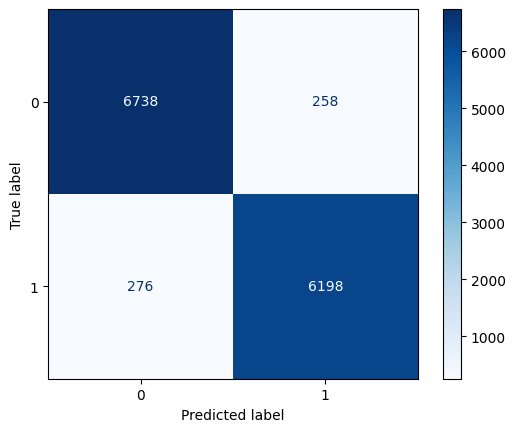

In [122]:
model = CatBoostClassifier(verbose=1)
model.fit(X_train_w,y_train_w)
y_pred_cat=model.predict(X_test_w)
print(accuracy_score(y_test_w,y_pred_cat))
print(classification_report(y_test_w,y_pred_cat))
ConfusionMatrixDisplay.from_predictions(y_test_tf,y_pred_cat,cmap="Blues")
plt.show()

      Iter       Train Loss   Remaining Time 
         1           1.3350            7.95m
         2           1.2916            7.82m
         3           1.2527            7.71m
         4           1.2166            7.62m
         5           1.1834            7.54m
         6           1.1526            7.46m
         7           1.1231            7.37m
         8           1.0978            7.29m
         9           1.0735            7.21m
        10           1.0504            7.14m
        20           0.8842            6.36m
        30           0.7773            5.56m
        40           0.6993            4.77m
        50           0.6401            3.97m
        60           0.5930            3.18m
        70           0.5554            2.39m
        80           0.5228            1.60m
        90           0.4947           48.04s
       100           0.4706            0.00s
0.9112843355605048
              precision    recall  f1-score   support

           0       0.92  

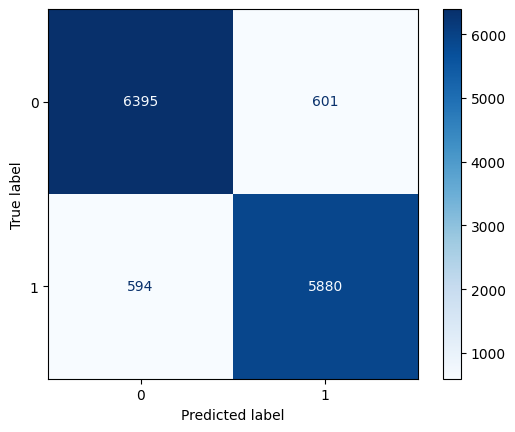

In [123]:
gbc.fit(X_train_w,y_train_w)
y_pred_gbcw=gbc.predict(X_test_w)
print(accuracy_score(y_test_w,y_pred_gbcw))
print(classification_report(y_test_w,y_pred_gbcw))
ConfusionMatrixDisplay.from_predictions(y_test_w,y_pred_gbcw,cmap="Blues")
plt.show()

In [124]:
x,y=data['corrected'],data['label']

In [125]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer('xlm-r-distilroberta-base-paraphrase-v1')
embeddings = model.encode(x.astype(str).tolist(), show_progress_bar=True)


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/724 [00:00<?, ?B/s]

...

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.10M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/1404 [00:00<?, ?it/s]

In [126]:
X = embeddings

In [127]:
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(X, y, test_size=0.2, random_state=42)

[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    1.6s finished


0.9809576837416482


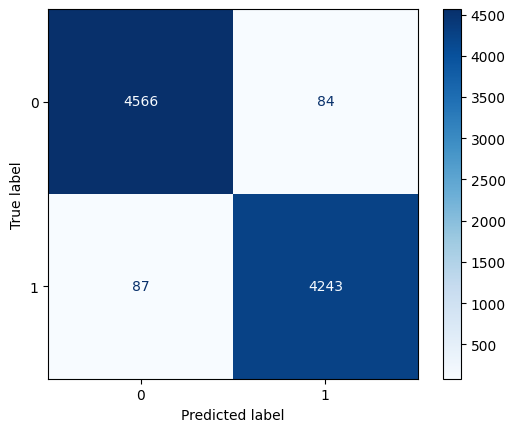

In [128]:
lg_tf = LogisticRegression(max_iter=2000,verbose=1)
lg_tf.fit(X_train_s,y_train_s)
y_pred_b=lg_tf.predict(X_test_s)
print(accuracy_score(y_test_s,y_pred_b))
ConfusionMatrixDisplay.from_predictions(y_test_s,y_pred_b,cmap="Blues")
plt.show()

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done  42 tasks      | elapsed:   25.3s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:   57.4s finished
[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.0s
[Parallel(n_jobs=4)]: Done 100 out of 100 | elapsed:    0.1s finished


0.9409799554565702


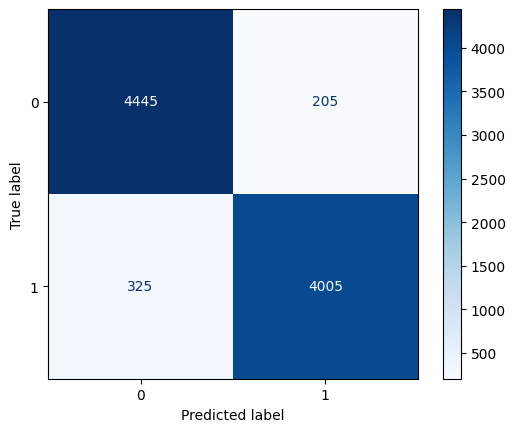

In [129]:
rf.fit(X_train_s,y_train_s)
y_pred_b=rf.predict(X_test_s)
print(accuracy_score(y_test_s,y_pred_b))
ConfusionMatrixDisplay.from_predictions(y_test_s,y_pred_b,cmap="Blues")
plt.show()

0.8602449888641426


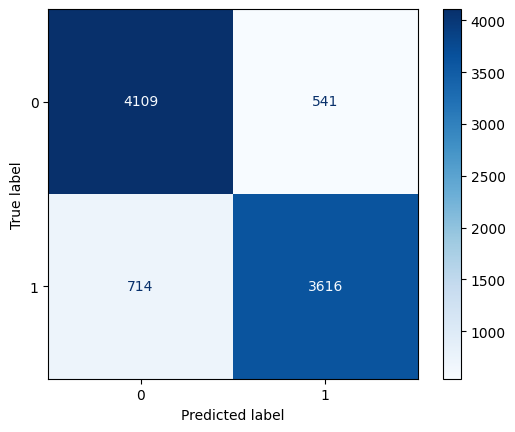

In [130]:
dt.fit(X_train_s,y_train_s)
y_pred_b=dt.predict(X_test_s)
print(accuracy_score(y_test_s,y_pred_b))
ConfusionMatrixDisplay.from_predictions(y_test_s,y_pred_b,cmap="Blues")
plt.show()


[LightGBM] [Info] Number of positive: 17087, number of negative: 18831
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.244391 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 195840
[LightGBM] [Info] Number of data points in the train set: 35918, number of used features: 768
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.475722 -> initscore=-0.097187
[LightGBM] [Info] Start training from score -0.097187
0.9557906458797327
              precision    recall  f1-score   support

           0       0.95      0.96      0.96      4650
           1       0.96      0.95      0.95      4330

    accuracy                           0.96      8980
   macro avg       0.96      0.96      0.96      8980
weighted avg       0.96      0.96      0.96      8980



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


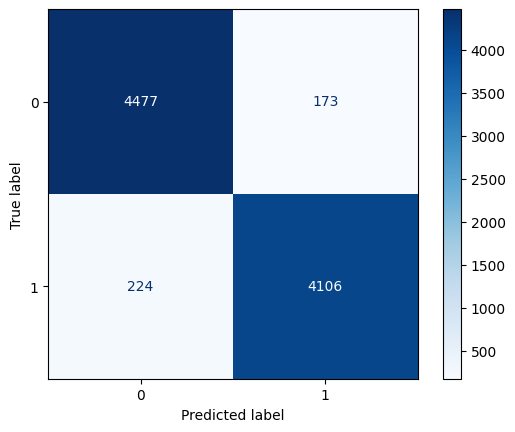

In [131]:
lgbm.fit(X_train_s,y_train_s)
y_pred_lgbm=lgbm.predict(X_test_s)
print(accuracy_score(y_test_s,y_pred_lgbm))
print(classification_report(y_test_s,y_pred_lgbm))
ConfusionMatrixDisplay.from_predictions(y_test_s,y_pred_lgbm,cmap="Blues")
plt.show()

Learning rate set to 0.047539
0:	learn: 0.6586878	total: 183ms	remaining: 3m 3s
1:	learn: 0.6288118	total: 348ms	remaining: 2m 53s
2:	learn: 0.6012222	total: 484ms	remaining: 2m 40s
3:	learn: 0.5756366	total: 619ms	remaining: 2m 34s
4:	learn: 0.5529549	total: 760ms	remaining: 2m 31s
5:	learn: 0.5320911	total: 896ms	remaining: 2m 28s
6:	learn: 0.5143141	total: 1.03s	remaining: 2m 26s
7:	learn: 0.4984775	total: 1.17s	remaining: 2m 25s
8:	learn: 0.4825058	total: 1.3s	remaining: 2m 23s
9:	learn: 0.4670700	total: 1.44s	remaining: 2m 22s
10:	learn: 0.4542117	total: 1.57s	remaining: 2m 20s
11:	learn: 0.4427956	total: 1.69s	remaining: 2m 19s
12:	learn: 0.4320831	total: 1.82s	remaining: 2m 18s
13:	learn: 0.4213114	total: 1.95s	remaining: 2m 17s
14:	learn: 0.4113996	total: 2.08s	remaining: 2m 16s
15:	learn: 0.4026148	total: 2.21s	remaining: 2m 15s
16:	learn: 0.3936477	total: 2.34s	remaining: 2m 15s
17:	learn: 0.3861957	total: 2.47s	remaining: 2m 14s
18:	learn: 0.3780797	total: 2.6s	remaining: 2m

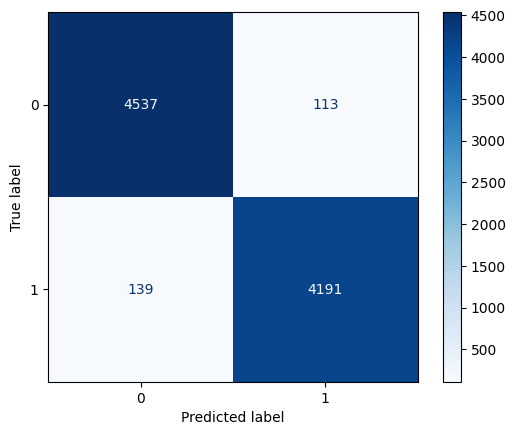

In [132]:
model = CatBoostClassifier(verbose=1)
model.fit(X_train_s,y_train_s)
y_pred_cat=model.predict(X_test_s)
print(accuracy_score(y_test_s,y_pred_cat))
print(classification_report(y_test_s,y_pred_cat))
ConfusionMatrixDisplay.from_predictions(y_test_s,y_pred_cat,cmap="Blues")
plt.show()

      Iter       Train Loss   Remaining Time 
         1           1.3061           23.10m
         2           1.2412           22.96m
         3           1.1858           22.72m
         4           1.1358           22.87m
         5           1.0925           22.55m
         6           1.0547           22.28m
         7           1.0187           22.02m
         8           0.9847           21.76m
         9           0.9544           21.51m
        10           0.9246           21.31m
        20           0.7292           18.89m
        30           0.6167           16.52m
        40           0.5399           14.16m
        50           0.4855           11.81m
        60           0.4437            9.45m
        70           0.4100            7.09m
        80           0.3827            4.74m
        90           0.3593            2.37m
       100           0.3388            0.00s
0.9350779510022271
              precision    recall  f1-score   support

           0       0.94  

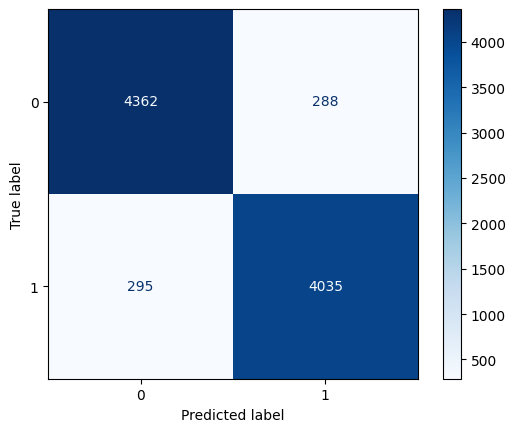

In [133]:
gbc.fit(X_train_s,y_train_s)
y_pred_gbcw=gbc.predict(X_test_s)
print(accuracy_score(y_test_s,y_pred_gbcw))
print(classification_report(y_test_s,y_pred_gbcw))
ConfusionMatrixDisplay.from_predictions(y_test_s,y_pred_gbcw,cmap="Blues")
plt.show()

In [134]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score
import numpy as np

In [135]:

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = []

In [136]:
for train_idx, val_idx in skf.split(X, y):
    # Select the training and validation sets using the indices
    X_train, X_test = X[train_idx], X[val_idx]
    y_train, y_test = y[train_idx], y[val_idx]
    
    # Fit the model
    lg_tf.fit(X_train, y_train)
    
    # Predict on validation set
    preds = lg_tf.predict(X_test)
    
    # Compute accuracy
    score = accuracy_score(y_test, preds)
    scores.append(score)

print("Fold scores:", scores)
print("Mean score:", np.mean(scores))


[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    1.9s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    2.7s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    2.1s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    2.3s finished


Fold scores: [0.9838530066815144, 0.9817371937639198, 0.9812917594654789, 0.9816237888406282, 0.9822920147009689]
Mean score: 0.9821595526905019


[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    2.2s finished
